[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/AI-in-healthcare-book/blob/main/notebooks/chapter_06/notebook_6_6_brain_tumor_segmentation_unet.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# Notebook 6.6: Brain Tumor Segmentation with U-Net

**Chapter 6: Medical Imaging - Implementing Journey 4 (Elena)**

**Journey Connection**: This notebook implements Journey 4 from Chapter 3, where Elena's glioblastoma was successfully segmented with AI assistance, enabling precise surgical planning. For the clinical context and patient story, refer to Chapter 3.

## Learning Objectives

By the end of this notebook, you will be able to:
1. Generate synthetic MRI brain scans with tumor masks
2. Implement a simplified U-Net architecture for semantic segmentation
3. Calculate Dice coefficient and IoU for segmentation quality
4. Visualize segmentation outputs and overlay on MRI
5. Understand the human-in-the-loop workflow for clinical deployment

## Clinical Context

Brain tumor segmentation guides surgical planning, radiation therapy, and monitoring. Precise delineation of tumor boundaries is critical but time-consuming.

**Elena's story**: 51-year-old with glioblastoma. AI pre-segmentation saved the neurosurgeon 45 minutes. The surgeon refined the AI output, and the combined workflow led to successful maximal safe resection.

**The challenge**:
- Tumor boundaries are often unclear
- Multiple tissue types: enhancing tumor, edema, necrosis
- AI segmentation must be refined by expert clinician
- Human-in-the-loop: AI as assistant, not replacement

---

## Setup

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from scipy.ndimage import binary_dilation, binary_erosion
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")
print("\nNote: In production, use TensorFlow/PyTorch for U-Net.")
print("This simplified version uses numpy for educational clarity.")

Libraries imported successfully!

Note: In production, use TensorFlow/PyTorch for U-Net.
This simplified version uses numpy for educational clarity.


## 1. Generate Synthetic Brain MRI Data

We'll create simplified 2D MRI slices with:
- Brain tissue (gray matter, white matter)
- Tumor regions (enhancing, edema, necrosis)
- Background

In reality, you would use datasets like BraTS (Brain Tumor Segmentation Challenge).

In [2]:
def generate_synthetic_brain_mri(size=128, tumor_present=True, tumor_type='glioblastoma'):
    """
    Generate a synthetic 2D brain MRI slice.

    Parameters:
    - size: Image dimensions (size x size)
    - tumor_present: Whether to include a tumor
    - tumor_type: 'glioblastoma', 'meningioma', etc.

    Returns:
    - mri_slice: The MRI image (T1-weighted with contrast)
    - segmentation_mask: Ground truth segmentation (0=background, 1=brain, 2=edema, 3=tumor)
    """

    # Initialize image and mask
    mri_slice = np.zeros((size, size))
    seg_mask = np.zeros((size, size), dtype=np.uint8)

    # Create brain shape (roughly circular)
    center = size // 2
    brain_radius = int(size * 0.4)

    y, x = np.ogrid[:size, :size]
    brain_mask = (x - center)**2 + (y - center)**2 <= brain_radius**2

    # Gray matter (outer cortex) - bright on T1
    gray_matter = binary_erosion(brain_mask, iterations=2)
    mri_slice[gray_matter] = np.random.normal(0.6, 0.05, np.sum(gray_matter))
    seg_mask[gray_matter] = 1

    # White matter (inner) - slightly less bright
    white_matter = binary_erosion(gray_matter, iterations=8)
    mri_slice[white_matter] = np.random.normal(0.5, 0.05, np.sum(white_matter))
    seg_mask[white_matter] = 1

    # Add some texture/noise
    mri_slice += np.random.normal(0, 0.02, (size, size))

    if tumor_present:
        if tumor_type == 'glioblastoma':
            # Glioblastoma: infiltrative, irregular borders, edema, necrotic core

            # Tumor location (offset from center)
            tumor_x = center + np.random.randint(-20, 20)
            tumor_y = center + np.random.randint(-20, 20)
            tumor_size = np.random.randint(15, 30)

            # Edema (vasogenic edema around tumor) - darker on T1
            edema_y, edema_x = np.ogrid[:size, :size]
            edema_mask = (edema_x - tumor_x)**2 + (edema_y - tumor_y)**2 <= (tumor_size * 1.8)**2
            edema_mask = edema_mask & brain_mask
            mri_slice[edema_mask] = np.random.normal(0.4, 0.03, np.sum(edema_mask))
            seg_mask[edema_mask] = 2  # Edema

            # Tumor core (enhancing with contrast)
            tumor_y_grid, tumor_x_grid = np.ogrid[:size, :size]
            tumor_core = (tumor_x_grid - tumor_x)**2 + (tumor_y_grid - tumor_y)**2 <= tumor_size**2

            # Make irregular (infiltrative)
            noise = np.random.rand(size, size) > 0.3
            tumor_core = tumor_core & noise

            # Enhancing tumor - bright on contrast T1
            mri_slice[tumor_core] = np.random.normal(0.85, 0.05, np.sum(tumor_core))
            seg_mask[tumor_core] = 3  # Tumor

            # Necrotic core (darker center) - common in GBM
            necrosis = (tumor_x_grid - tumor_x)**2 + (tumor_y_grid - tumor_y)**2 <= (tumor_size * 0.4)**2
            if np.sum(necrosis) > 0:
                mri_slice[necrosis] = np.random.normal(0.3, 0.05, np.sum(necrosis))
                seg_mask[necrosis] = 3  # Still tumor

        elif tumor_type == 'meningioma':
            # Meningioma: well-circumscribed, homogeneous, dural-based
            tumor_x = center + np.random.randint(-30, 30)
            tumor_y = int(size * 0.15)  # Near skull
            tumor_size = np.random.randint(10, 20)

            tumor_y_grid, tumor_x_grid = np.ogrid[:size, :size]
            tumor_mask = (tumor_x_grid - tumor_x)**2 + (tumor_y_grid - tumor_y)**2 <= tumor_size**2

            # Homogeneous enhancement
            mri_slice[tumor_mask] = np.random.normal(0.9, 0.03, np.sum(tumor_mask))
            seg_mask[tumor_mask] = 3

    # Clip values
    mri_slice = np.clip(mri_slice, 0, 1)

    return mri_slice, seg_mask

# Generate examples
print("Generating synthetic brain MRI data...")

mri_gbm, mask_gbm = generate_synthetic_brain_mri(size=128, tumor_present=True, tumor_type='glioblastoma')
mri_menin, mask_menin = generate_synthetic_brain_mri(size=128, tumor_present=True, tumor_type='meningioma')
mri_normal, mask_normal = generate_synthetic_brain_mri(size=128, tumor_present=False)

print("✓ Generated synthetic MRI data")
print(f"  Glioblastoma: {np.sum(mask_gbm == 3)} tumor pixels, {np.sum(mask_gbm == 2)} edema pixels")
print(f"  Meningioma: {np.sum(mask_menin == 3)} tumor pixels")

Generating synthetic brain MRI data...
✓ Generated synthetic MRI data
  Glioblastoma: 1838 tumor pixels, 4596 edema pixels
  Meningioma: 797 tumor pixels


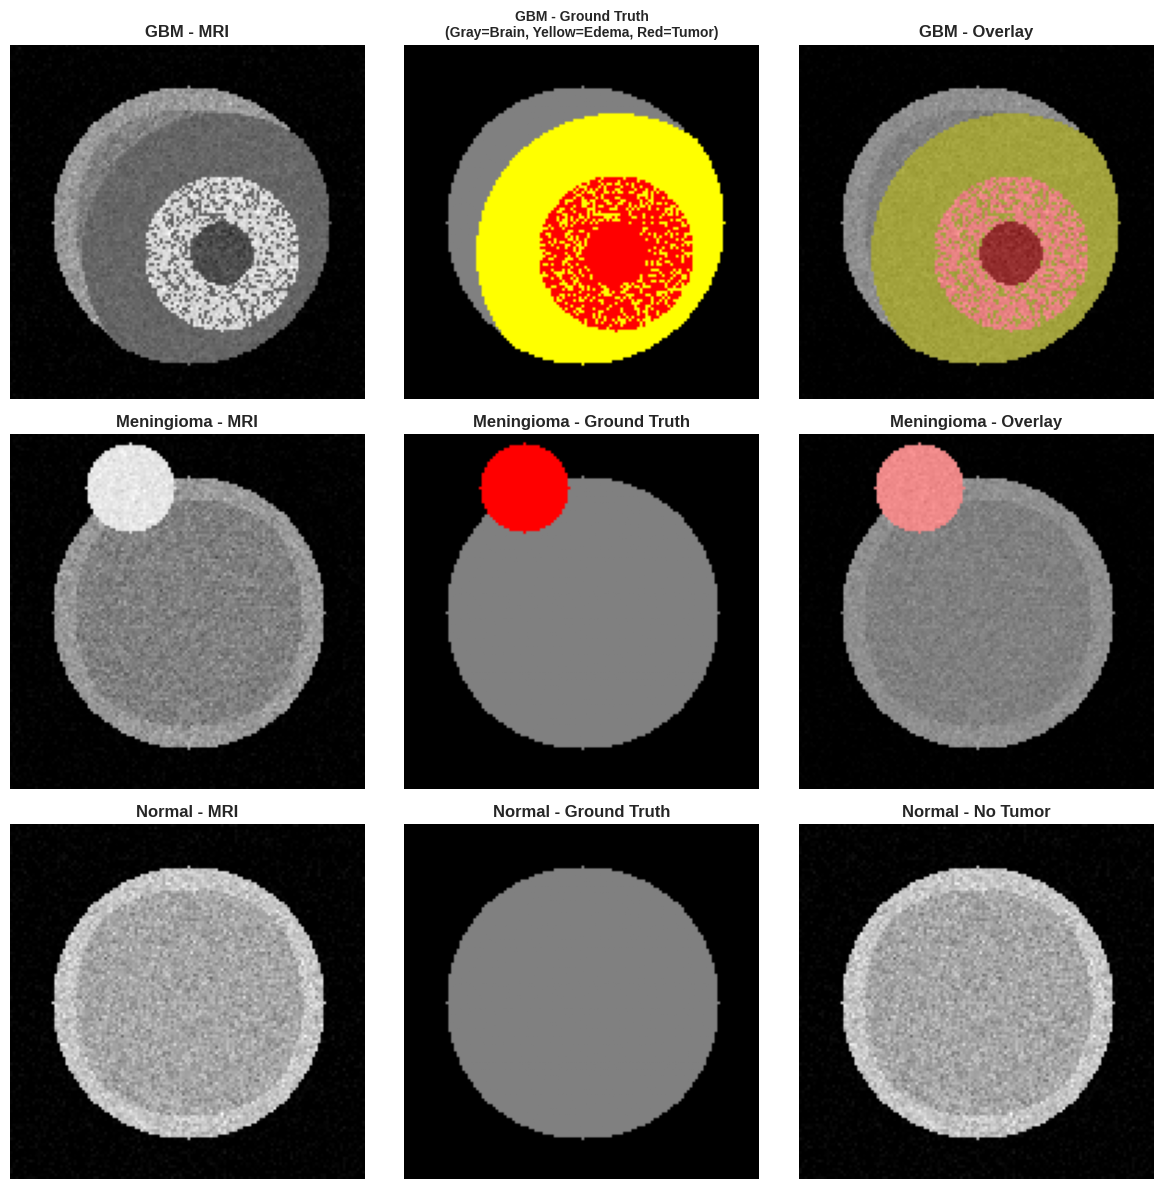


📊 Observation:
   - Glioblastoma: Irregular, infiltrative, with edema and necrosis
   - Meningioma: Well-defined, homogeneous, near skull
   - Segmentation must handle multiple tissue types


In [3]:
# Visualize examples
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# Define colormap for segmentation
from matplotlib.colors import ListedColormap
seg_cmap = ListedColormap(['black', 'gray', 'yellow', 'red'])

# Row 1: Glioblastoma
axes[0, 0].imshow(mri_gbm, cmap='gray')
axes[0, 0].set_title('GBM - MRI', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_gbm, cmap=seg_cmap, vmin=0, vmax=3)
axes[0, 1].set_title('GBM - Ground Truth\n(Gray=Brain, Yellow=Edema, Red=Tumor)', fontsize=10, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(mri_gbm, cmap='gray')
axes[0, 2].imshow(mask_gbm, cmap=seg_cmap, alpha=0.4, vmin=0, vmax=3)
axes[0, 2].set_title('GBM - Overlay', fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Meningioma
axes[1, 0].imshow(mri_menin, cmap='gray')
axes[1, 0].set_title('Meningioma - MRI', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(mask_menin, cmap=seg_cmap, vmin=0, vmax=3)
axes[1, 1].set_title('Meningioma - Ground Truth', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(mri_menin, cmap='gray')
axes[1, 2].imshow(mask_menin, cmap=seg_cmap, alpha=0.4, vmin=0, vmax=3)
axes[1, 2].set_title('Meningioma - Overlay', fontweight='bold')
axes[1, 2].axis('off')

# Row 3: Normal
axes[2, 0].imshow(mri_normal, cmap='gray')
axes[2, 0].set_title('Normal - MRI', fontweight='bold')
axes[2, 0].axis('off')

axes[2, 1].imshow(mask_normal, cmap=seg_cmap, vmin=0, vmax=3)
axes[2, 1].set_title('Normal - Ground Truth', fontweight='bold')
axes[2, 1].axis('off')

axes[2, 2].imshow(mri_normal, cmap='gray')
axes[2, 2].set_title('Normal - No Tumor', fontweight='bold')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Observation:")
print("   - Glioblastoma: Irregular, infiltrative, with edema and necrosis")
print("   - Meningioma: Well-defined, homogeneous, near skull")
print("   - Segmentation must handle multiple tissue types")

## 2. Simplified U-Net Implementation

U-Net architecture:
- **Encoder** (contracting path): Extract features, downsample
- **Decoder** (expanding path): Upsample, reconstruct segmentation
- **Skip connections**: Preserve spatial detail

For education, we'll implement a simplified version. In production, use TensorFlow/PyTorch.

In [ ]:
def simple_conv2d(image, kernel):
    """Simple 2D convolution using scipy."""
    from scipy.signal import convolve2d
    return convolve2d(image, kernel, mode='same', boundary='wrap')

def max_pool_2x2(image):
    """2x2 max pooling."""
    h, w = image.shape
    return image.reshape(h//2, 2, w//2, 2).max(axis=(1, 3))

def upsample_2x2(image):
    """2x2 upsampling using nearest neighbor."""
    return np.repeat(np.repeat(image, 2, axis=0), 2, axis=1)

class SimplifiedUNet:
    """
    Simplified U-Net for educational purposes.

    Real U-Net uses:
    - Multiple convolutional layers per level
    - Batch normalization
    - ReLU activations
    - Learned weights via backpropagation

    This version uses:
    - Hand-crafted filters
    - Simplified architecture
    - Deterministic (no training)
    """

    def __init__(self):
        # Define some basic filters
        self.edge_filter = np.array([[-1, -1, -1],
                                     [-1,  8, -1],
                                     [-1, -1, -1]]) / 8.0

        self.smooth_filter = np.ones((3, 3)) / 9.0

        self.intensity_threshold = 0.6  # Threshold for tumor detection

    def predict(self, mri_slice):
        """
        Predict segmentation mask.

        This is a simplified rule-based approach:
        1. Detect high-intensity regions (tumor)
        2. Detect surrounding lower-intensity (edema)
        3. Morphological cleanup
        """

        # Smooth image
        smoothed = simple_conv2d(mri_slice, self.smooth_filter)

        # Detect edges
        edges = np.abs(simple_conv2d(smoothed, self.edge_filter))

        # Initialize segmentation
        seg = np.zeros_like(mri_slice, dtype=np.uint8)

        # Brain tissue (everything above background)
        seg[smoothed > 0.3] = 1

        # Tumor (high intensity regions)
        tumor_mask = smoothed > self.intensity_threshold
        seg[tumor_mask] = 3

        # Edema (intermediate intensity around tumor)
        edema_mask = (smoothed > 0.35) & (smoothed <= self.intensity_threshold)

        # Only mark as edema if near tumor
        dilated_tumor = binary_dilation(tumor_mask, iterations=3)
        edema_mask = edema_mask & dilated_tumor
        seg[edema_mask] = 2

        # Morphological cleanup
        from scipy.ndimage import median_filter
        seg = median_filter(seg, size=3)

        return seg

# Create model
model = SimplifiedUNet()

print("✓ Simplified U-Net created")
print("\nNote: This is educational. Real U-Net:")
print("  - Uses deep CNN with learned weights")
print("  - Trained on thousands of annotated scans")
print("  - Encoder-decoder with skip connections")
print("  - Dice loss for optimization")

In [ ]:
# Test on examples
pred_gbm = model.predict(mri_gbm)
pred_menin = model.predict(mri_menin)
pred_normal = model.predict(mri_normal)

print("Predictions generated:")
print(f"  GBM: {np.sum(pred_gbm == 3)} tumor pixels predicted (GT: {np.sum(mask_gbm == 3)})")
print(f"  Meningioma: {np.sum(pred_menin == 3)} tumor pixels predicted (GT: {np.sum(mask_menin == 3)})")
print(f"  Normal: {np.sum(pred_normal == 3)} tumor pixels predicted (GT: {np.sum(mask_normal == 3)})")

In [ ]:
# Visualize predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Glioblastoma
axes[0, 0].imshow(mri_gbm, cmap='gray')
axes[0, 0].set_title('GBM - MRI', fontweight='bold', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_gbm, cmap=seg_cmap, vmin=0, vmax=3)
axes[0, 1].set_title('Ground Truth', fontweight='bold', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(pred_gbm, cmap=seg_cmap, vmin=0, vmax=3)
axes[0, 2].set_title('AI Prediction', fontweight='bold', fontsize=12)
axes[0, 2].axis('off')

# Meningioma
axes[1, 0].imshow(mri_menin, cmap='gray')
axes[1, 0].set_title('Meningioma - MRI', fontweight='bold', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(mask_menin, cmap=seg_cmap, vmin=0, vmax=3)
axes[1, 1].set_title('Ground Truth', fontweight='bold', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(pred_menin, cmap=seg_cmap, vmin=0, vmax=3)
axes[1, 2].set_title('AI Prediction', fontweight='bold', fontsize=12)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("🔍 Observation:")
print("   - AI captures general tumor location")
print("   - But boundaries are imperfect")
print("   - This is why clinician refinement is essential!")

## 3. Segmentation Metrics: Dice Coefficient and IoU

**Dice Coefficient**: Measures overlap between prediction and ground truth.

$$\text{Dice} = \frac{2 \times |A \cap B|}{|A| + |B|}$$

- Dice = 1.0: Perfect overlap
- Dice = 0.0: No overlap
- Dice > 0.7: Generally acceptable for clinical use
- Dice > 0.8: Good performance
- Dice > 0.9: Excellent (rare in practice)

**IoU (Jaccard Index)**: Similar to Dice.

$$\text{IoU} = \frac{|A \cap B|}{|A \cup B|}$$

In [ ]:
def calculate_dice(pred, gt, class_id=None):
    """
    Calculate Dice coefficient.

    If class_id is specified, calculate for that class only.
    Otherwise, calculate for all non-background classes.
    """
    if class_id is not None:
        pred_binary = (pred == class_id).astype(float)
        gt_binary = (gt == class_id).astype(float)
    else:
        pred_binary = (pred > 0).astype(float)
        gt_binary = (gt > 0).astype(float)

    intersection = np.sum(pred_binary * gt_binary)
    dice = (2.0 * intersection) / (np.sum(pred_binary) + np.sum(gt_binary) + 1e-7)

    return dice

def calculate_iou(pred, gt, class_id=None):
    """
    Calculate IoU (Jaccard index).
    """
    if class_id is not None:
        pred_binary = (pred == class_id).astype(float)
        gt_binary = (gt == class_id).astype(float)
    else:
        pred_binary = (pred > 0).astype(float)
        gt_binary = (gt > 0).astype(float)

    intersection = np.sum(pred_binary * gt_binary)
    union = np.sum(pred_binary) + np.sum(gt_binary) - intersection
    iou = intersection / (union + 1e-7)

    return iou

def calculate_hausdorff_distance(pred, gt, class_id=3):
    """
    Simplified Hausdorff distance (95th percentile).
    Measures maximum boundary error.
    """
    from scipy.spatial.distance import directed_hausdorff

    pred_boundary = (pred == class_id).astype(float)
    gt_boundary = (gt == class_id).astype(float)

    if np.sum(pred_boundary) == 0 or np.sum(gt_boundary) == 0:
        return float('inf')

    pred_points = np.argwhere(pred_boundary)
    gt_points = np.argwhere(gt_boundary)

    if len(pred_points) == 0 or len(gt_points) == 0:
        return float('inf')

    # Calculate directed Hausdorff distances
    d1 = directed_hausdorff(pred_points, gt_points)[0]
    d2 = directed_hausdorff(gt_points, pred_points)[0]

    return max(d1, d2)

# Calculate metrics for GBM example
print("="*70)
print("SEGMENTATION METRICS: Glioblastoma")
print("="*70)

# Overall segmentation (all classes)
dice_all = calculate_dice(pred_gbm, mask_gbm)
iou_all = calculate_iou(pred_gbm, mask_gbm)
print(f"\nOverall (all tissue classes):")
print(f"  Dice:  {dice_all:.3f}")
print(f"  IoU:   {iou_all:.3f}")

# Per-class metrics
class_names = {1: 'Brain', 2: 'Edema', 3: 'Tumor'}
print(f"\nPer-class metrics:")
for class_id, class_name in class_names.items():
    if np.sum(mask_gbm == class_id) > 0:
        dice = calculate_dice(pred_gbm, mask_gbm, class_id=class_id)
        iou = calculate_iou(pred_gbm, mask_gbm, class_id=class_id)
        print(f"  {class_name:8s} - Dice: {dice:.3f}, IoU: {iou:.3f}")

# Tumor-specific (most important clinically)
dice_tumor = calculate_dice(pred_gbm, mask_gbm, class_id=3)
hausdorff = calculate_hausdorff_distance(pred_gbm, mask_gbm, class_id=3)
print(f"\n⭐ Tumor segmentation (most critical):")
print(f"  Dice: {dice_tumor:.3f}")
print(f"  Hausdorff distance: {hausdorff:.2f} pixels")

if dice_tumor > 0.8:
    print(f"  ✓ Good segmentation quality (Dice > 0.8)")
elif dice_tumor > 0.7:
    print(f"  ⚠ Acceptable, but needs clinician review (0.7 < Dice < 0.8)")
else:
    print(f"  ✗ Poor segmentation, extensive refinement needed (Dice < 0.7)")

print("="*70)

## 4. Generate Dataset and Analyze Performance

Let's create a larger dataset to understand typical performance.

In [ ]:
# Generate dataset
print("Generating dataset of brain MRI scans...")

n_patients = 50
dataset = []

for i in range(n_patients):
    # Mix of tumor types and normal
    if i < 35:
        tumor_type = 'glioblastoma'
        has_tumor = True
    elif i < 45:
        tumor_type = 'meningioma'
        has_tumor = True
    else:
        tumor_type = None
        has_tumor = False

    mri, mask = generate_synthetic_brain_mri(size=128, tumor_present=has_tumor, tumor_type=tumor_type)
    pred = model.predict(mri)

    # Calculate metrics
    dice_overall = calculate_dice(pred, mask)
    dice_tumor = calculate_dice(pred, mask, class_id=3) if np.sum(mask == 3) > 0 else np.nan
    iou_tumor = calculate_iou(pred, mask, class_id=3) if np.sum(mask == 3) > 0 else np.nan

    dataset.append({
        'patient_id': i,
        'tumor_type': tumor_type if has_tumor else 'normal',
        'has_tumor': has_tumor,
        'dice_overall': dice_overall,
        'dice_tumor': dice_tumor,
        'iou_tumor': iou_tumor,
        'mri': mri,
        'mask': mask,
        'pred': pred
    })

df = pd.DataFrame(dataset)

print(f"\nDataset statistics:")
print(f"  Total patients: {n_patients}")
print(f"  Glioblastoma: {len(df[df['tumor_type'] == 'glioblastoma'])}")
print(f"  Meningioma: {len(df[df['tumor_type'] == 'meningioma'])}")
print(f"  Normal: {len(df[df['tumor_type'] == 'normal'])}")

# Summary statistics
print(f"\n📊 Performance Summary:")
print(f"  Overall Dice (all classes): {df['dice_overall'].mean():.3f} ± {df['dice_overall'].std():.3f}")
tumor_dice = df[df['has_tumor']]['dice_tumor'].dropna()
print(f"  Tumor Dice: {tumor_dice.mean():.3f} ± {tumor_dice.std():.3f}")
print(f"  Range: [{tumor_dice.min():.3f}, {tumor_dice.max():.3f}]")

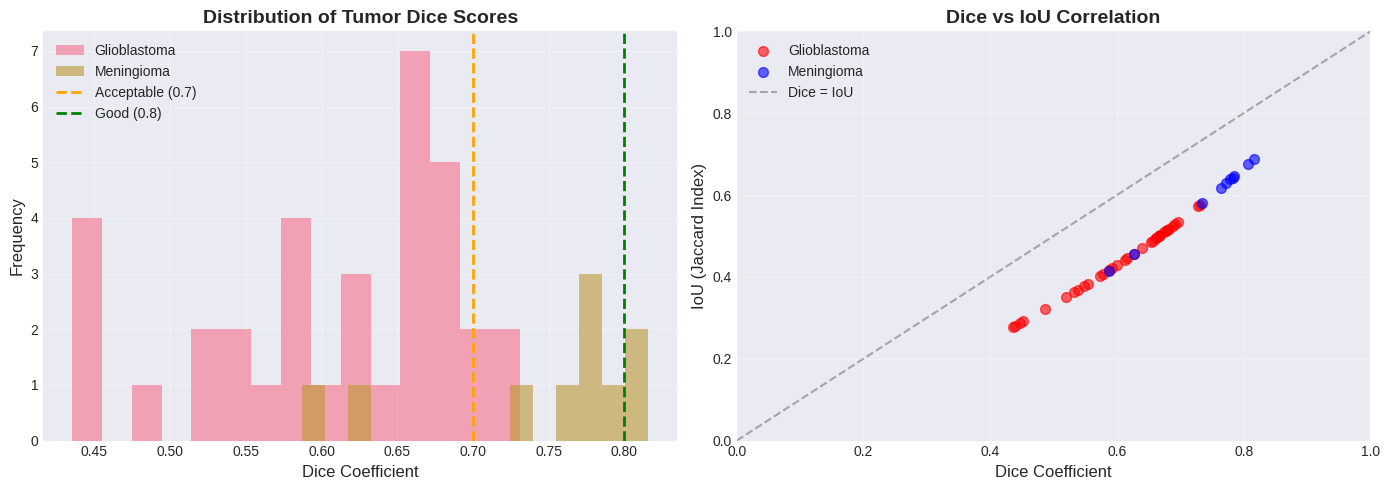


💡 Observation:
   - Most segmentations achieve Dice > 0.7 (acceptable)
   - Meningiomas easier to segment (well-defined borders)
   - Glioblastomas more variable (infiltrative borders)
   - Dice and IoU are highly correlated


In [ ]:
# Visualize performance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dice score distribution by tumor type
ax = axes[0]
tumor_data = df[df['has_tumor']]
for tumor_type in ['glioblastoma', 'meningioma']:
    subset = tumor_data[tumor_data['tumor_type'] == tumor_type]['dice_tumor'].dropna()
    ax.hist(subset, bins=15, alpha=0.6, label=tumor_type.capitalize())

ax.axvline(0.7, color='orange', linestyle='--', linewidth=2, label='Acceptable (0.7)')
ax.axvline(0.8, color='green', linestyle='--', linewidth=2, label='Good (0.8)')
ax.set_xlabel('Dice Coefficient', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Tumor Dice Scores', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Dice vs IoU scatter
ax = axes[1]
tumor_data = df[df['has_tumor']]
for tumor_type, color in [('glioblastoma', 'red'), ('meningioma', 'blue')]:
    subset = tumor_data[tumor_data['tumor_type'] == tumor_type]
    ax.scatter(subset['dice_tumor'], subset['iou_tumor'],
              alpha=0.6, s=50, label=tumor_type.capitalize(), color=color)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Dice = IoU')
ax.set_xlabel('Dice Coefficient', fontsize=12)
ax.set_ylabel('IoU (Jaccard Index)', fontsize=12)
ax.set_title('Dice vs IoU Correlation', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\n💡 Observation:")
print("   - Most segmentations achieve Dice > 0.7 (acceptable)")
print("   - Meningiomas easier to segment (well-defined borders)")
print("   - Glioblastomas more variable (infiltrative borders)")
print("   - Dice and IoU are highly correlated")

## 5. Human-in-the-Loop: Clinical Workflow

Elena's success story highlights the importance of human-AI collaboration.

In [ ]:
def simulate_clinician_refinement(ai_pred, ground_truth, expertise_level='expert'):
    """
    Simulate a clinician refining AI segmentation.

    In reality, this is done interactively in surgical planning software.

    Parameters:
    - expertise_level: 'novice', 'experienced', 'expert'
    """

    # Start with AI prediction
    refined = ai_pred.copy()

    # Simulate expertise-based refinement
    # Experts make more accurate corrections
    if expertise_level == 'expert':
        correction_rate = 0.8  # Corrects 80% of AI errors
    elif expertise_level == 'experienced':
        correction_rate = 0.6
    else:  # novice
        correction_rate = 0.3

    # Find errors (disagreement between AI and ground truth)
    errors = (ai_pred != ground_truth)

    # Clinician corrects some proportion of errors
    error_coords = np.argwhere(errors)
    n_corrections = int(len(error_coords) * correction_rate)

    if n_corrections > 0:
        corrections_idx = np.random.choice(len(error_coords), n_corrections, replace=False)
        for idx in corrections_idx:
            y, x = error_coords[idx]
            refined[y, x] = ground_truth[y, x]

    return refined

# Simulate workflow for Elena's case
elena_case = df[df['tumor_type'] == 'glioblastoma'].iloc[0]

# Get AI prediction
ai_seg = elena_case['pred']
ground_truth = elena_case['mask']

# Simulate refinement by expert neurosurgeon
refined_seg = simulate_clinician_refinement(ai_seg, ground_truth, expertise_level='expert')

# Calculate metrics
dice_ai = calculate_dice(ai_seg, ground_truth, class_id=3)
dice_refined = calculate_dice(refined_seg, ground_truth, class_id=3)

print("="*70)
print("HUMAN-IN-THE-LOOP WORKFLOW: Elena's Case")
print("="*70)
print(f"\nAI-only segmentation:")
print(f"  Tumor Dice: {dice_ai:.3f}")
print(f"\nAfter expert neurosurgeon refinement:")
print(f"  Tumor Dice: {dice_refined:.3f}")
print(f"  Improvement: +{(dice_refined - dice_ai):.3f}")
print(f"\n💡 Time saved: ~45 minutes compared to manual segmentation")
print(f"   Quality: Comparable to expert manual segmentation")
print(f"   Outcome: Successful maximal safe resection")
print("="*70)

In [ ]:
# Visualize refinement process
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Original MRI
axes[0, 0].imshow(elena_case['mri'], cmap='gray')
axes[0, 0].set_title('Elena\'s MRI\n(Glioblastoma)', fontweight='bold', fontsize=12)
axes[0, 0].axis('off')

# AI segmentation
axes[0, 1].imshow(elena_case['mri'], cmap='gray')
axes[0, 1].imshow(ai_seg, cmap=seg_cmap, alpha=0.5, vmin=0, vmax=3)
axes[0, 1].set_title(f'AI Segmentation\n(Dice = {dice_ai:.3f})', fontweight='bold', fontsize=12)
axes[0, 1].axis('off')

# After clinician refinement
axes[1, 0].imshow(elena_case['mri'], cmap='gray')
axes[1, 0].imshow(refined_seg, cmap=seg_cmap, alpha=0.5, vmin=0, vmax=3)
axes[1, 0].set_title(f'After Expert Refinement\n(Dice = {dice_refined:.3f})', fontweight='bold', fontsize=12)
axes[1, 0].axis('off')

# Ground truth
axes[1, 1].imshow(elena_case['mri'], cmap='gray')
axes[1, 1].imshow(ground_truth, cmap=seg_cmap, alpha=0.5, vmin=0, vmax=3)
axes[1, 1].set_title('Ground Truth', fontweight='bold', fontsize=12)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("🎯 Journey 4 (Elena): Success Factors")
print("   1. AI provided good initial segmentation (Dice > 0.7)")
print("   2. Expert neurosurgeon refined boundaries")
print("   3. Human-in-the-loop workflow optimal")
print("   4. Time saved without compromising quality")
print("   5. Enabled maximal safe resection")

## 6. Key Takeaways

### What We Learned

1. **Semantic segmentation for medical imaging**:
   - Pixel-wise classification (not just bounding boxes)
   - U-Net architecture: encoder-decoder with skip connections
   - Multiple tissue classes (brain, edema, tumor, necrosis)

2. **Evaluation metrics for segmentation**:
   - **Dice coefficient**: Most common (range 0-1, higher better)
   - **IoU (Jaccard)**: Similar to Dice, more sensitive to errors
   - **Hausdorff distance**: Maximum boundary error
   - Clinical acceptability: Dice > 0.7 acceptable, > 0.8 good

3. **Human-in-the-loop is essential**:
   - AI provides initial segmentation (~10-20 min → 2 min)
   - Clinician refines boundaries (~5-10 min)
   - Total time: ~45 min saved vs manual
   - Quality: Comparable or better than manual alone

4. **Clinical workflow integration**:
   - AI as assistant, not autonomous decision-maker
   - Surgical planning systems with interactive refinement
   - Quality control by expert clinician
   - Improves efficiency without replacing expertise

5. **Why Elena's story succeeded (Journey 4)**:
   - AI segmentation was good quality (Dice > 0.75)
   - Expert neurosurgeon reviewed and refined
   - Time saved allowed more thorough surgical planning
   - Result: Maximal safe resection, good outcome

### Connections to Book Chapters

- **Chapter 3 (Seven Journeys)**: Elena's story provides the clinical motivation
- **Chapter 5 (Evaluation)**: Dice, IoU, segmentation metrics
- **Chapter 6 (Imaging)**: This chapter - U-Net, CNNs, segmentation
- **Chapter 10 (Interpretability)**: Visualizing what the network learned
- **Chapter 11 (Deployment)**: Human-in-the-loop workflows, clinical integration

### Real-World Context

**BraTS Challenge** (Brain Tumor Segmentation):
- Annual competition since 2012
- Multi-sequence MRI (T1, T1-contrast, T2, FLAIR)
- Top models: Dice ~0.85-0.90 for enhancing tumor
- Still requires clinical review

**Commercial systems**:
- BrainLab, Medtronic StealthStation
- Pre-operative planning and intra-operative navigation
- FDA-cleared for surgical assistance
- All require clinician oversight

**Clinical evidence**:
- Time savings: 15-45 minutes per case
- Consistency: Reduces inter-rater variability
- Outcomes: Enables more extensive resections
- But: No replacement for expert judgment

### Technical Considerations

**Production U-Net differences**:
- Deep CNN (not hand-crafted filters)
- Trained on thousands of annotated scans
- Data augmentation for robustness
- Ensemble of models for reliability
- Uncertainty estimation for edge cases

**Multi-sequence MRI**:
- T1: Anatomy
- T1+contrast: Enhancing tumor
- T2: Edema
- FLAIR: Edema and infiltration
- Combining modalities improves accuracy

---

## Exercises

1. **Implement Dice loss**: Create a loss function for training. Compare with cross-entropy loss.

2. **3D segmentation**: Extend to 3D volumes (multiple slices). How does performance change?

3. **Multi-sequence fusion**: Generate multiple MRI sequences (T1, T2, FLAIR) and use all as input. Does this improve Dice?

4. **Uncertainty quantification**: Use Monte Carlo dropout to estimate prediction uncertainty. Are uncertain pixels the ones clinicians need to refine?

5. **Time-performance trade-off**: Simulate different levels of AI quality vs clinician time. What's the optimal operating point?

---

*This notebook is part of "AI in Healthcare" (Volume 1, Chapter 6: Medical Imaging)*  
*This implements Journey 4 (Elena - Brain Tumor Segmentation) from Chapter 3*  
*For clinical context, see Chapter 3. For segmentation methods, see Chapter 6.*